In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("..")

from src.data_loader import DataLoader

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

✅ Libraries imported!


In [2]:
# Load Dataset
loader = DataLoader(data_dir=r"C:\Users\gulna\demand-forecasting-cloud\data\raw", sample_size=50000)
loader.run_pipeline()
train, test, store = loader.get_data()

print(f"\nData shapes:")
print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

INFO:src.data_loader:Loading raw data files...
INFO:src.data_loader:Loaded 1115 stores
INFO:src.data_loader:Loaded 50000 training records
INFO:src.data_loader:Loaded 41088 test records
INFO:src.data_loader:Merging store information...
INFO:src.data_loader:Store info merged



DATASET INFORMATION
Shape: (50000, 18)
Date Range: 2015-06-17 00:00:00 to 2015-07-31 00:00:00

Columns:
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']

Missing Values:
Store                            0
DayOfWeek                        0
Date                             0
Sales                            0
Customers                        0
Open                             0
Promo                            0
StateHoliday                     0
SchoolHoliday                    0
StoreType                        0
Assortment                       0
CompetitionDistance            135
CompetitionOpenSinceMonth    15873
CompetitionOpenSinceYear     15873
Promo2                           0
Promo2SinceWeek              24404
Promo2SinceYear              24404
PromoInt

In [3]:
print("SALES STATISTICS:")
print(train['Sales'].describe())
print(f"\nCustomers Statistics:")
print(train['Customers'].describe())

SALES STATISTICS:
count    50000.000000
mean      6100.766320
std       3684.824412
min          0.000000
25%       4214.000000
50%       6002.000000
75%       8036.000000
max      41551.000000
Name: Sales, dtype: float64

Customers Statistics:
count    50000.00000
mean       639.38436
std        436.21514
min          0.00000
25%        439.00000
50%        608.00000
75%        812.00000
max       4783.00000
Name: Customers, dtype: float64


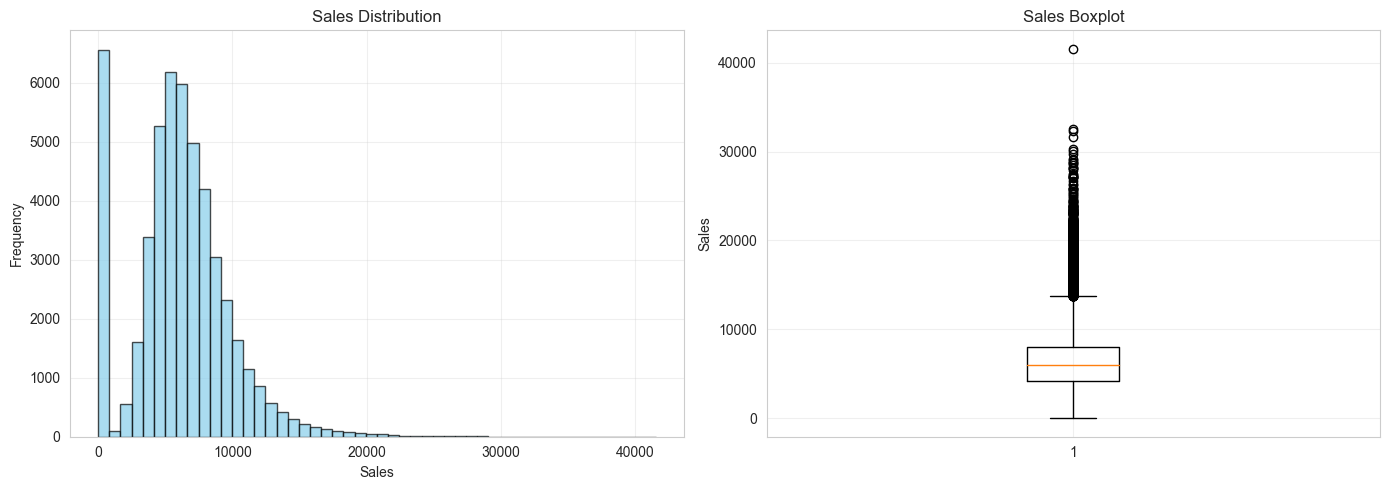

✅ Saved: 01_sales_distribution.png


In [4]:
# Sales Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(train['Sales'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Sales Distribution')
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(train['Sales'])
axes[1].set_ylabel('Sales')
axes[1].set_title('Sales Boxplot')
axes[1].grid(True, alpha=0.3)

# Save image
plt.tight_layout()
plt.savefig(r'C:\Users\gulna\demand-forecasting-cloud\results\01_sales_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("01_sales_distribution.png saved")

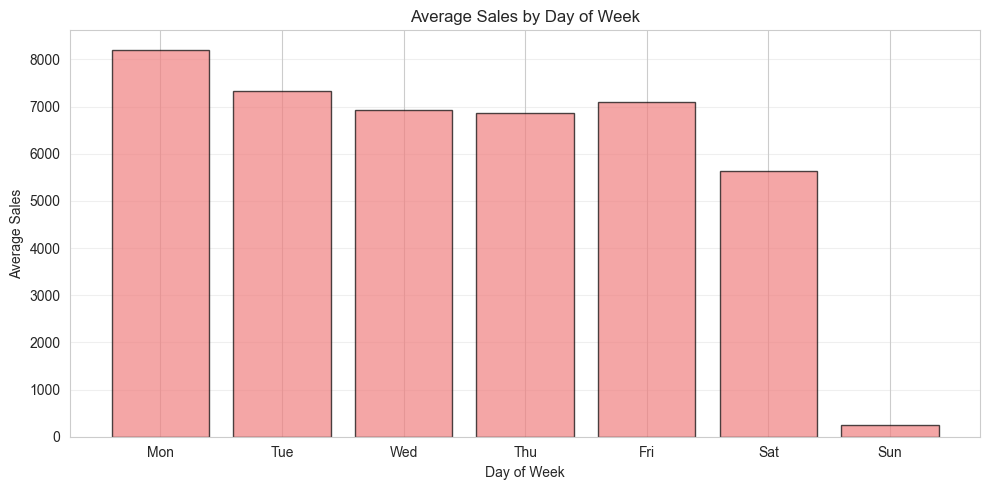

✅ Saved: 02_sales_by_day.png


In [5]:
# Average Sales by Day of Week 
train['DayOfWeek'] = train['Date'].dt.dayofweek
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

daily_avg = train.groupby('DayOfWeek')['Sales'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(7), daily_avg.values, color='lightcoral', edgecolor='black', alpha=0.7)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Sales')
ax.set_title('Average Sales by Day of Week')
ax.set_xticks(range(7))
ax.set_xticklabels(day_names)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(r'C:\Users\gulna\demand-forecasting-cloud\results\02_sales_by_day.png', dpi=100, bbox_inches='tight')
plt.show()

print("02_sales_by_day.png saved")

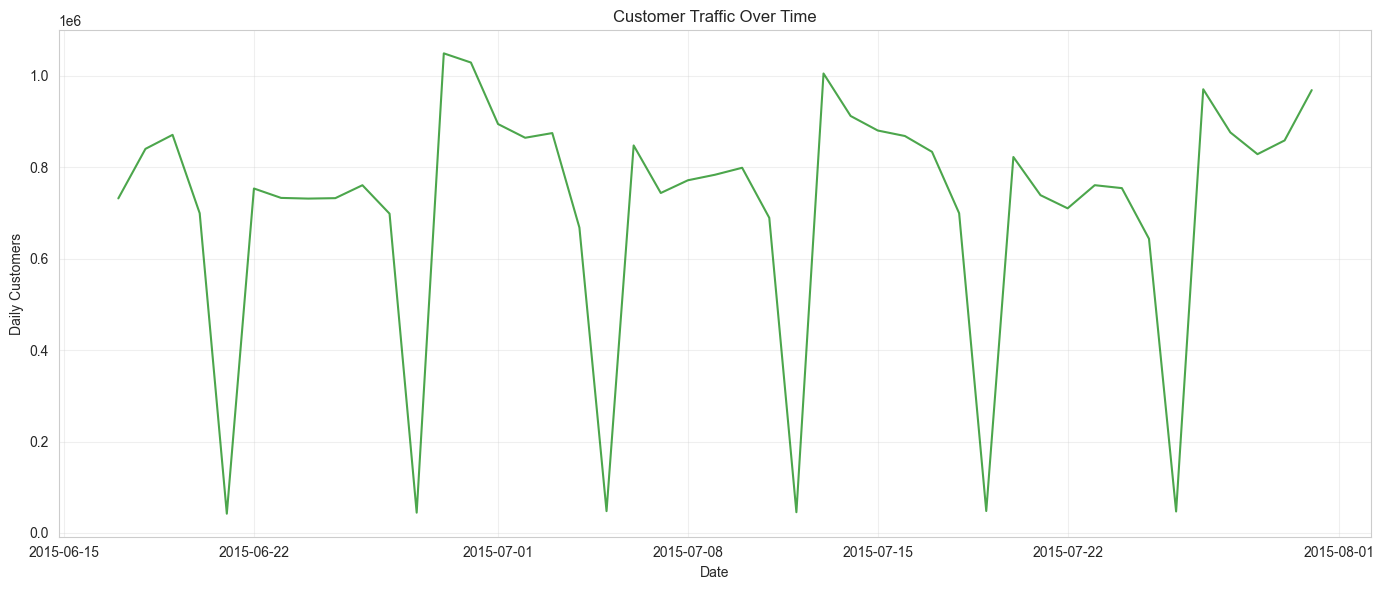

✅ Saved: 03_customers_over_time.png


In [6]:
# Customer Traffic Over Time
daily_customers = train.groupby('Date')['Customers'].sum()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily_customers.index, daily_customers.values, linewidth=1.5, alpha=0.7, color='green')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Customers')
ax.set_title('Customer Traffic Over Time')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\gulna\demand-forecasting-cloud\results\03_customers_over_time.png', dpi=100, bbox_inches='tight')
plt.show()

print("03_customers_over_time.png saved")

Missing Values:
CompetitionDistance            135
CompetitionOpenSinceMonth    15873
CompetitionOpenSinceYear     15873
Promo2SinceWeek              24404
Promo2SinceYear              24404
PromoInterval                24404
dtype: int64


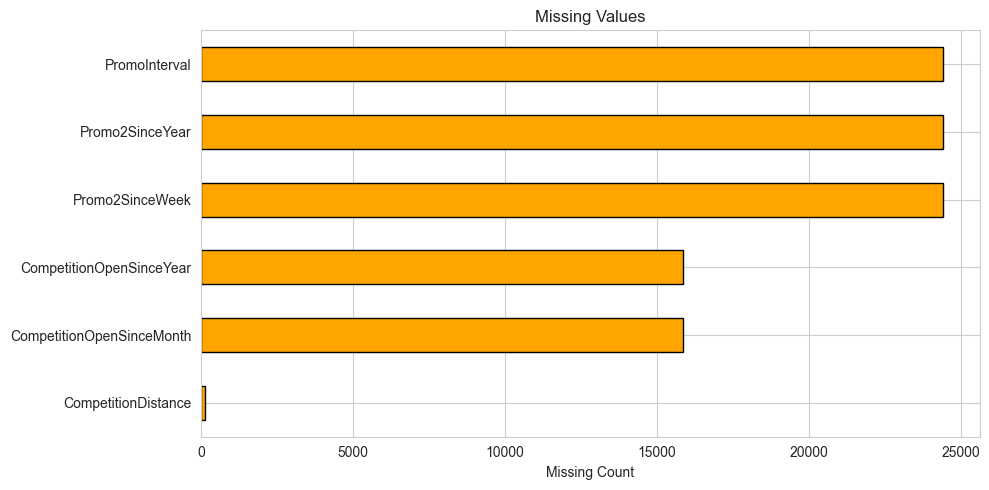

✅ Saved: 04_missing_values.png


In [7]:
# Missing Values
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100)

print("Missing Values:")
print(missing[missing > 0])

if missing.sum() > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    missing[missing > 0].plot(kind='barh', ax=ax, color='orange', edgecolor='black')
    ax.set_xlabel('Missing Count')
    ax.set_title('Missing Values')
    plt.tight_layout()
    plt.savefig(r'C:\Users\gulna\demand-forecasting-cloud\results\04_missing_values.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("04_missing_values.png saved")
else:
    print("No missing values!")

In [8]:
# Key Insights
print("\n" + "="*70)
print("KEY INSIGHTS FOR DEMAND FORECASTING")
print("="*70)
print(f"Date Range: {train['Date'].min()} to {train['Date'].max()}")
print(f"Total Stores: {train['Store'].nunique()}")
print(f"Avg Daily Sales: ${train['Sales'].mean():.2f}")
print(f"Peak Sales: ${train['Sales'].max():.2f}")
print(f"Min Sales: ${train['Sales'].min():.2f}")
print(f"Days Closed (Sales=0): {(train['Sales'] == 0).sum()}")
print(f"Avg Customers: {train['Customers'].mean():.2f}")
print("="*70)


KEY INSIGHTS FOR DEMAND FORECASTING
📊 Date Range: 2015-06-17 00:00:00 to 2015-07-31 00:00:00
🏪 Total Stores: 1115
💰 Avg Daily Sales: $6100.77
📈 Peak Sales: $41551.00
📉 Min Sales: $0.00
🚫 Days Closed (Sales=0): 6551
👥 Avg Customers: 639.38
